# T001 · Compound data acquisition (ChEMBL)

**Note:** This talktorial is a part of TeachOpenCADD, a platform that aims to teach domain-specific skills and to provide pipeline templates as starting points for research projects.

Authors:

- Svetlana Leng, CADD seminar 2017, Volkamer lab, Charité/FU Berlin
- Paula Junge, CADD seminar 2018, Volkamer lab, Charité/FU Berlin
- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)

__Talktorial T001__: This talktorial is part of the TeachOpenCADD pipeline described in the [first TeachOpenCADD paper](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x), comprising of talktorials T001-T010.

## Aim of this talktorial

In this notebook, we will learn more about the ChEMBL database and how to extract data from ChEMBL, i.e. (compound, activity data) pairs for a target of interest. These data sets can be used for many cheminformatics tasks, such as similarity search, clustering or machine learning.

Our work here will include finding compounds which were tested against a certain target and filtering available bioactivity data.

### Contents in *Theory*

* ChEMBL database
    * ChEMBL web services
    * ChEMBL webresource client
* Compound activity measures
    * IC50 measure
    * pIC50 value

### Contents in *Practical*

**Goal: Get a list of compounds with bioactivity data for a given target**

* Connect to ChEMBL database
* Get target data (example: EGFR kinase)
    * Fetch and download target data
    * Select target ChEMBL ID
* Get bioactivity data
    * Fetch and download bioactivity data for target
    * Preprocess and filter bioactivity data
* Get compound data
    * Fetch and download compound data
    * Preprocess and filter compound data
* Output bioactivity-compound data
    * Merge bioactivity and compound data, and add pIC50 values
    * Draw molecules with highest pIC50
    * Freeze bioactivity data to ChEMBL 27
    * Write output file

### References

* ChEMBL bioactivity database: [Gaulton *et al.*, <i>Nucleic Acids Res.</i> (2017), 45(Database issue), D945–D954](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5210557/)
* ChEMBL web services: [Davies *et al.*, <i>Nucleic Acids Res.</i> (2015), <b>43</b>, 612-620](https://academic.oup.com/nar/article/43/W1/W612/2467881)
* [ChEMBL web-interface](https://www.ebi.ac.uk/chembl/)
*  GitHub [ChEMBL webrescource client](https://github.com/chembl/chembl_webresource_client)
* The EBI RDF platform: [Jupp *et al.*, <i>Bioinformatics </i> (2014), 30(9), 1338-9](https://www.ncbi.nlm.nih.gov/pubmed/24413672)
* Info on half maximal inhibitory concentration: [(p)IC50](https://en.wikipedia.org/wiki/IC50)
* [UniProt website](https://www.uniprot.org/)

## Theory

### ChEMBL database
>"ChEMBL is a manually curated database of bioactive molecules with drug-like properties. It brings together chemical, bioactivity and genomic data to aid the translation of genomic information into effective new drugs." ([ChEMBL website](https://www.ebi.ac.uk/chembl/))

* Open large-scale bioactivity database
* **Current data content (as of 09.2020, ChEMBL 27):**
    * \>1.9 million distinct compounds
    * \>16 million activity values
    * Assays are mapped to ~13,000 targets
* **Data sources** include scientific literature, PubChem bioassays, Drugs for Neglected Diseases Initiative (DNDi), BindingDB database, ...
* ChEMBL data can be accessed via a [web-interface](https://www.ebi.ac.uk/chembl/), the [EBI-RDF platform](https://www.ncbi.nlm.nih.gov/pubmed/24413672) and the [ChEMBL webrescource client](https://github.com/chembl/chembl_webresource_client)

#### ChEMBL web services

* RESTful web service
* ChEMBL web service version 2.x resource schema:

![ChEMBL web service schema](images/chembl_webservices_schema_diagram.jpg)

*Figure 1:*
"[ChEMBL web service schema diagram](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4489243/figure/F2/). The oval shapes represent ChEMBL web service resources and the line between two resources indicates that they share a common attribute. The arrow direction shows where the primary information about a resource type can be found. A dashed line indicates the relationship between two resources behaves differently. For example, the `Image` resource provides a graphical based representation of a `Molecule`."
Figure and description taken from: [<i>Nucleic Acids Res.</i> (2015), <b>43</b>, 612-620](https://academic.oup.com/nar/article/43/W1/W612/2467881).

#### ChEMBL webresource client

* Python client library for accessing ChEMBL data
* Handles interaction with the HTTPS protocol
* Lazy evaluation of results -> reduced number of network requests

### Compound activity measures

#### IC50 measure

* [Half maximal inhibitory concentration](https://en.wikipedia.org/wiki/IC50)
* Indicates how much of a particular drug or other substance is needed to inhibit a given biological process by half

![Wiki_Example_IC50_curve_demonstrating_visually_how_IC50_is_derived](images/Wiki_Example_IC50_curve_demonstrating_visually_how_IC50_is_derived.png)

*Figure 2:* Visual demonstration of how to derive an IC50 value:
(i) Arrange inhibition data on y-axis and log(concentration) on x-axis. (ii) Identify maximum and minimum inhibition. (iii) The IC50 is the concentration at which the curve passes through the 50% inhibition level. Figure ["Example IC50 curve demonstrating visually how IC50 is derived"](https://en.wikipedia.org/wiki/IC50#/media/File:Example_IC50_curve_demonstrating_visually_how_IC50_is_derived.png) by JesseAlanGordon is licensed under [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).

#### pIC50 value

* To facilitate the comparison of IC50 values, which have a large value range and are given in different units (M, nM, ...), often pIC50 values are used
* The pIC50 is the negative log of the IC50 value when converted to molar units:
    $ pIC_{50} = -log_{10}(IC_{50}) $, where $ IC_{50}$ is specified in units of M
* Higher pIC50 values indicate exponentially greater potency of the drug
* Note that the conversion can be adapted to the respective IC50 unit, e.g. for nM: $pIC_{50} = -log_{10}(IC_{50}*10^{-9})= 9-log_{10}(IC_{50}) $

Other activity measures:

Besides, IC50 and pIC50, other bioactivity measures are used, such as the equilibrium constant [KI](https://en.wikipedia.org/wiki/Equilibrium_constant) and the half maximal effective concentration  [EC50](https://en.wikipedia.org/wiki/EC50).

## Practical

In the following, we want to download all molecules that have been tested against our target of interest, the **epidermal growth factor receptor** ([**EGFR**](https://www.uniprot.org/uniprot/P00533)) kinase.

### Connect to ChEMBL database

First, the ChEMBL webresource client as well as other Python libraries are imported.

In [ ]:
import math
from pathlib import Path

import requests

import pandas as pd
from rdkit.Chem import PandasTools

In [192]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

Next, we create resource objects for API access.

In [193]:
BASE_URL = "https://www.ebi.ac.uk/chembl/api/data"

# Function to get JSON data from a the ChEMBL REST endpoint, handling pagination 
def get_json(endpoint, params=None):
    params = params.copy() if params else {}
    params.setdefault("limit", 1000)

    records = []
    offset = 0

    while True:
        params["offset"] = offset

        response = requests.get(
            f"{BASE_URL}/{endpoint}.json",
            params=params,
            headers={"Accept": "application/json"},
            timeout=30,
        )

        response.raise_for_status()
        data = response.json()
        collection_name = next(
            key
            for key in data.keys()
            if isinstance(data[key], list)
        )

        batch = data[collection_name]

        if not batch:
            break

        records.extend(batch)

        if len(batch) < params["limit"]:
            break

        offset += params["limit"]

    return records

In [194]:
# Search for targets in chembl from uniprot_id and return a pandas DataFrame with the results
def get_targets(uniprot_id):
    targets = get_json(
        "target",
        {
            "target_components__accession": uniprot_id
        }
    )

    targets = pd.DataFrame(targets)

    # Add columns to the DataFrame if it is not empty
    if not targets.empty:
        columns = [
            "target_chembl_id",
            "organism",
            "pref_name",
            "target_type",
        ]

        targets = targets[columns]

    return targets

In [195]:
# Search for activities in chembl using a target_chembl_id and return a pandas DataFrame with the results
def get_activities(
    target_chembl_id,
    activity_type="IC50",
    relation="=",
    assay_type="B",
):

    activities = get_json(
        "activity",
        {
            "target_chembl_id": target_chembl_id,
            "type": activity_type,
            "relation": relation,
            "assay_type": assay_type,
        },
    )

    activities = pd.DataFrame(activities)

    if not activities.empty:
        columns = [
            "activity_id",
            "assay_chembl_id",
            "assay_description",
            "assay_type",
            "molecule_chembl_id",
            "type",
            "standard_units",
            "relation",
            "standard_value",
            "target_chembl_id",
            "target_organism",
        ]

        available = [
            c for c in columns
            if c in activities.columns
        ]

        activities = activities[available]

    return activities


In [196]:
# Search for compounds in chembl using a list of molecule_chembl_ids and return a pandas DataFrame with the results
def get_compounds(molecule_chembl_ids, batch_size=100):

    molecule_chembl_ids = list(set(molecule_chembl_ids))
    compounds = []

    for start in range(0, len(molecule_chembl_ids), batch_size):
        batch = molecule_chembl_ids[start:start + batch_size]
        ids = ";".join(batch)

        data = get_json(
            f"molecule/set/{ids}"
        )
        for molecule in data:
            compounds.append(
                {
                    "molecule_chembl_id": molecule["molecule_chembl_id"],
                    "molecule_structures": molecule["molecule_structures"],
                }
            )

        print(
            f"Retrieved {len(compounds)} compounds...",
            end="\r"
        )

    return pd.DataFrame(compounds)

### Get target data (EGFR kinase)

* Get UniProt ID of the target of interest (EGFR kinase:  [P00533](http://www.uniprot.org/uniprot/P00533)) from [UniProt website](https://www.uniprot.org/)
* Use UniProt ID to get target information

Select a different UniProt ID, if you are interested in another target.

In [199]:
uniprot_id = "P00533"

#### Fetch and download target data from ChEMBL

In [200]:
# Get target information from ChEMBL but restrict it to specified values only
targets = get_targets(uniprot_id)

print(f"The type of targets is {type(targets)}")

The type of targets is <class 'pandas.DataFrame'>


In [201]:
# Let's have a look at the target information we retrieved from ChEMBL
targets.head()

,target_chembl_id,organism,pref_name,target_type
0,CHEMBL203,Homo sapiens,Epidermal growth factor receptor,SINGLE PROTEIN
1,CHEMBL2111431,Homo sapiens,Epidermal growth factor receptor and ErbB2 (HE...,PROTEIN FAMILY
2,CHEMBL2363049,Homo sapiens,Epidermal growth factor receptor,PROTEIN FAMILY
3,CHEMBL3137284,Homo sapiens,MER intracellular domain/EGFR extracellular do...,CHIMERIC PROTEIN
4,CHEMBL4523680,Homo sapiens,Protein cereblon/Epidermal growth factor receptor,PROTEIN-PROTEIN INTERACTION


#### Select target (target ChEMBL ID)

After checking the entries, we select the first entry as our target of interest:

`CHEMBL203`: It is a single protein and represents the human Epidermal growth factor receptor (EGFR, also named erbB1)

In [202]:
target = targets.iloc[0]
target

target_chembl_id                           CHEMBL203
organism                                Homo sapiens
pref_name           Epidermal growth factor receptor
target_type                           SINGLE PROTEIN
Name: 0, dtype: str

Save selected ChEMBL ID.

In [203]:
chembl_id = target.target_chembl_id
print(f"The target ChEMBL ID is {chembl_id}")

The target ChEMBL ID is CHEMBL203


### Get bioactivity data

Now, we want to query bioactivity data for the target of interest.

#### Fetch and download bioactivity data for the target from ChEMBL

In this step, we fetch the bioactivity data and filter it to only consider

* human proteins,
* bioactivity type IC50,
* exact measurements (relation `'='`), and
* binding data (assay type `'B'`).

In [204]:
bioactivities = get_activities(chembl_id)

print(
    f"Length and type of bioactivities object: "
    f"{len(bioactivities)}, {type(bioactivities)}"
)


Length and type of bioactivities object: 17686, <class 'pandas.DataFrame'>


In [205]:
# Check the number of unique molecules
print(bioactivities["molecule_chembl_id"].nunique())

10280


Each entry in our bioactivity set holds the following information:

In [206]:
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,IC50,nM,=,41.0,CHEMBL203,Homo sapiens
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,IC50,nM,=,170.0,CHEMBL203,Homo sapiens
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,IC50,nM,=,9300.0,CHEMBL203,Homo sapiens
3,32770,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL306988,IC50,nM,=,500000.0,CHEMBL203,Homo sapiens
4,32772,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL66879,IC50,nM,=,3000000.0,CHEMBL203,Homo sapiens


#### Preprocess and filter bioactivity data

1. Convert `standard_value`'s datatype from `object` to `float`
2. Delete entries with missing values
3. Keep only entries with `standard_unit == nM`
4. Delete duplicate molecules
5. Reset `DataFrame` index
6. Rename columns

**1. Convert datatype of "standard_value" from "object" to "float"**

The field `standard_value` holds standardized (here IC50) values. In order to make these values usable in calculations later on, convert values to floats.

In [207]:
bioactivities.dtypes

activity_id           int64
assay_chembl_id         str
assay_description       str
assay_type              str
molecule_chembl_id      str
type                    str
standard_units          str
relation                str
standard_value          str
target_chembl_id        str
target_organism         str
dtype: object

In [208]:
bioactivities = bioactivities.astype({"standard_value": "float64"})
bioactivities.dtypes

activity_id             int64
assay_chembl_id           str
assay_description         str
assay_type                str
molecule_chembl_id        str
type                      str
standard_units            str
relation                  str
standard_value        float64
target_chembl_id          str
target_organism           str
dtype: object

**2. Delete entries with missing values**

Use the parameter `inplace=True` to drop values in the current `DataFrame` directly.

In [209]:
bioactivities.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (17685, 11)


**3. Keep only entries with "standard_unit == nM"**

We only want to keep bioactivity entries in `nM`, thus we remove all entries with other units.

In [210]:
print(f"Units in downloaded data: {bioactivities['standard_units'].unique()}")
print(
    f"Number of non-nM entries:\
    {bioactivities[bioactivities['standard_units'] != 'nM'].shape[0]}"
)

Units in downloaded data: <ArrowStringArray>
['nM', 'ug.mL-1', '/uM', '10^3 uM']
Length: 4, dtype: str
Number of non-nM entries:    73


In [211]:
bioactivities = bioactivities[bioactivities["standard_units"] == "nM"]
print(f"Units after filtering: {bioactivities['standard_units'].unique()}")

Units after filtering: <ArrowStringArray>
['nM']
Length: 1, dtype: str


In [212]:
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (17612, 11)


**4. Delete duplicate molecules**

Sometimes the same molecule (`molecule_chembl_id`) has been tested more than once, in this case, we only keep the first one.

Note other choices could be to keep the one with the best value or a mean value of all assay results for the respective compound.

In [213]:
bioactivities.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (10220, 11)


**5. Reset "DataFrame" index**

Since we deleted some rows, but we want to iterate over the index later, we reset the index to be continuous.

In [214]:
bioactivities.reset_index(drop=True, inplace=True)
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,IC50,nM,=,41.0,CHEMBL203,Homo sapiens
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,IC50,nM,=,170.0,CHEMBL203,Homo sapiens
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,IC50,nM,=,9300.0,CHEMBL203,Homo sapiens
3,32770,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL306988,IC50,nM,=,500000.0,CHEMBL203,Homo sapiens
4,32772,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL66879,IC50,nM,=,3000000.0,CHEMBL203,Homo sapiens


**6. Rename columns**

In [215]:
bioactivities.rename(
    columns={"standard_value": "IC50", "standard_units": "units"}, inplace=True
)
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,units,relation,IC50,target_chembl_id,target_organism
0,32260,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL68920,IC50,nM,=,41.0,CHEMBL203,Homo sapiens
1,32267,CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,CHEMBL69960,IC50,nM,=,170.0,CHEMBL203,Homo sapiens
2,32680,CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,CHEMBL137635,IC50,nM,=,9300.0,CHEMBL203,Homo sapiens
3,32770,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL306988,IC50,nM,=,500000.0,CHEMBL203,Homo sapiens
4,32772,CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,CHEMBL66879,IC50,nM,=,3000000.0,CHEMBL203,Homo sapiens


In [216]:
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (10220, 11)


In [217]:
print(len(bioactivities))
print(bioactivities["molecule_chembl_id"].nunique())

10220
10220


### Get compound data

We have a `DataFrame` containing all molecules tested against EGFR (with the respective measured bioactivity).

Now, we want to get the molecular structures of the molecules that are linked to respective bioactivity ChEMBL IDs.

#### Fetch and download compound data from ChEMBL

Let's have a look at the compounds from ChEMBL which we have defined bioactivity data for: We fetch compound ChEMBL IDs and structures for the compounds linked to our filtered bioactivity data. Given the data volume, this can take some time.

In [218]:
compounds = get_compounds(bioactivities["molecule_chembl_id"].unique())

In [219]:
compounds.head()

,molecule_chembl_id,molecule_structures
0,CHEMBL4532034,{'canonical_smiles': 'COc1ccncc1-c1cc(C(=O)/N=...
1,CHEMBL1946846,{'canonical_smiles': 'COc1nc(NCCN2CCOCC2)nc(Nc...
2,CHEMBL5085136,{'canonical_smiles': 'C=CC(=O)N1CCC2(CC1)CNC(=...
3,CHEMBL5999776,{'canonical_smiles': 'CCN1Cc2cccc([C@H](Nc3cc(...
4,CHEMBL201840,{'canonical_smiles': 'COC(=O)c1c(OC)c2ccccc2c2...


#### Preprocess and filter compound data

1. Remove entries with missing entries
2. Delete duplicate molecules (by molecule_chembl_id)
3. Get molecules with canonical SMILES

**1. Remove entries with missing molecule structure entry**

In [220]:
compounds.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds.shape}")

DataFrame shape: (10203, 2)


**2. Delete duplicate molecules**

In [221]:
compounds.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {compounds.shape}")

DataFrame shape: (10203, 2)


**3. Get molecules with canonical SMILES**

So far, we have multiple different molecular structure representations. We only want to keep the canonical SMILES.

In [222]:
compounds.iloc[0].molecule_structures.keys()

dict_keys(['canonical_smiles', 'molfile', 'standard_inchi', 'standard_inchi_key'])

In [223]:
compounds["smiles"] = compounds["molecule_structures"].apply(lambda x: x.get("canonical_smiles") if isinstance(x, dict) else None)
compounds.drop("molecule_structures", axis=1, inplace=True)
print(f"DataFrame shape: {compounds.shape}")

DataFrame shape: (10203, 2)


In [224]:
compounds.head()

,molecule_chembl_id,smiles
0,CHEMBL4532034,COc1ccncc1-c1cc(C(=O)/N=c2\[nH]c3ccccc3n2CC(C)...
1,CHEMBL1946846,COc1nc(NCCN2CCOCC2)nc(Nc2ccc(Cl)cc2)n1
2,CHEMBL5085136,C=CC(=O)N1CCC2(CC1)CNC(=O)c1cc(-c3ccnc(-c4ccc5...
3,CHEMBL5999776,CCN1Cc2cccc([C@H](Nc3cc(Cl)c4ncc(C#N)c(Nc5ccc(...
4,CHEMBL201840,COC(=O)c1c(OC)c2ccccc2c2oc3c(c12)C(=O)c1ccccc1...


Sanity check: Remove all molecules without a canonical SMILES string.

In [225]:
compounds.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds.shape}")

DataFrame shape: (10203, 2)


### Output (bioactivity-compound) data
**Summary of compound and bioactivity data**

In [226]:
print(f"Bioactivities filtered: {bioactivities.shape[0]}")
bioactivities.columns

Bioactivities filtered: 10220


Index(['activity_id', 'assay_chembl_id', 'assay_description', 'assay_type',
       'molecule_chembl_id', 'type', 'units', 'relation', 'IC50',
       'target_chembl_id', 'target_organism'],
      dtype='str')

In [227]:
print(f"Compounds filtered: {compounds.shape[0]}")
compounds.columns

Compounds filtered: 10203


Index(['molecule_chembl_id', 'smiles'], dtype='str')

#### Merge both datasets

Merge values of interest from `bioactivities_df` and `compounds_df` in an `output_df` based on the compounds' ChEMBL IDs (`molecule_chembl_id`), keeping the following columns:

* ChEMBL IDs: `molecule_chembl_id`
* SMILES: `smiles`
* units: `units`
* IC50: `IC50`

In [228]:
# Merge DataFrames
output_df = pd.merge(
    bioactivities[["molecule_chembl_id", "IC50", "units"]],
    compounds,
    on="molecule_chembl_id",
)

# Reset row indices
output_df.reset_index(drop=True, inplace=True)

print(f"Dataset with {output_df.shape[0]} entries.")

Dataset with 10203 entries.


In [229]:
output_df.dtypes

molecule_chembl_id        str
IC50                  float64
units                     str
smiles                    str
dtype: object

In [230]:
output_df.head(10)

,molecule_chembl_id,IC50,units,smiles
0,CHEMBL68920,41.0,nM,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...
1,CHEMBL69960,170.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...
2,CHEMBL137635,9300.0,nM,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12
3,CHEMBL306988,500000.0,nM,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1
4,CHEMBL66879,3000000.0,nM,O=C(O)/C=C/c1ccc(O)cc1
5,CHEMBL77085,96000.0,nM,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-]
6,CHEMBL443268,5310.0,nM,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...
7,CHEMBL76979,264000.0,nM,COc1cc(/C=C(\C#N)C(=O)O)cc(OC)c1O
8,CHEMBL76589,125.0,nM,N#CC(C#N)=C(N)/C(C#N)=C/c1ccc(O)cc1
9,CHEMBL76904,35000.0,nM,N#CC(C#N)=Cc1ccc(O)c(O)c1


#### Add pIC50 values

As you can see the low IC50 values are difficult to read (values are distributed over multiple scales), which is why we convert the IC50 values to pIC50.

In [231]:
def convert_ic50_to_pic50(IC50_value):
    pIC50_value = 9 - math.log10(IC50_value)
    return pIC50_value

In [232]:
# Apply conversion to each row of the compounds DataFrame
output_df["pIC50"] = output_df.apply(lambda x: convert_ic50_to_pic50(x.IC50), axis=1)

In [233]:
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL68920,41.0,nM,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216
1,CHEMBL69960,170.0,nM,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551
2,CHEMBL137635,9300.0,nM,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517
3,CHEMBL306988,500000.0,nM,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,3.301030
4,CHEMBL66879,3000000.0,nM,O=C(O)/C=C/c1ccc(O)cc1,2.522879


#### Draw compound data

Let's have a look at our collected data set.

First, we plot the pIC50 value distribution

array([[<Axes: title={'center': 'pIC50'}>]], dtype=object)

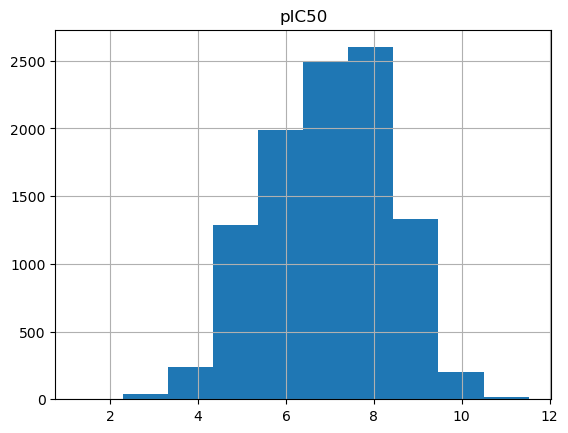

In [234]:
output_df.hist(column="pIC50")

In the next steps, we add a column for RDKit molecule objects to our `DataFrame` and look at the structures of the molecules with the highest pIC50 values.

In [235]:
# Add molecule column
PandasTools.AddMoleculeColumnToFrame(output_df, smilesCol="smiles")

Failed to patch pandas - unable to change molecule rendering


In [236]:
# Sort molecules by pIC50
output_df.sort_values(by="pIC50", ascending=False, inplace=True)

# Reset index
output_df.reset_index(drop=True, inplace=True)

Show the three most active molecules, i.e. molecules with the highest pIC50 values.

In [237]:
output_df.drop("smiles", axis=1).head(3)

,molecule_chembl_id,IC50,units,pIC50,ROMol
0,CHEMBL63786,0.003,nM,11.522879,<rdkit.Chem.rdchem.Mol object at 0x722669086960>
1,CHEMBL53711,0.006,nM,11.221849,<rdkit.Chem.rdchem.Mol object at 0x72266906f1b0>
2,CHEMBL35820,0.006,nM,11.221849,<rdkit.Chem.rdchem.Mol object at 0x7226690ec0b0>


In [238]:
# Prepare saving the dataset: Drop the ROMol column
output_df = output_df.drop("ROMol", axis=1)
print(f"DataFrame shape: {output_df.shape}")

DataFrame shape: (10203, 5)


#### Freeze output data to ChEMBL 27

This is a technical step: Usually, we would continue to work with the dataset that we just created (latest dataset).

However, here on the TeachOpenCADD platform, we prefer to freeze the dataset to a certain ChEMBL releases (i.e. [ChEMBL 27](http://doi.org/10.6019/CHEMBL.database.27)),
so that this talktorial and other talktorials downstream in our CADD pipeline do not change in the future (helping us to maintain the talktorials).

<div class="alert alert-block alert-info">

<b>Note:</b> If you prefer to run this notebook on the latest dataset or if you want to use it for another target, please comment the cell below.

</div>

In [239]:
# Disable this cell to unfreeze the dataset
output_df = pd.read_csv(
    DATA / "EGFR_compounds_ea055ef.csv", index_col=0, float_precision="round_trip"
)
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


In [240]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (5568, 5)


#### Write output data to file

We want to use this bioactivity-compound dataset in the following talktorials, thus we save the data as `csv` file.
Note that it is advisable to drop the molecule column (which only contains an image of the molecules) when saving the data.

In [241]:
output_df.to_csv(DATA / "EGFR_compounds.csv")
output_df.head()

,molecule_chembl_id,IC50,units,smiles,pIC50
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


In [242]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (5568, 5)


## Discussion

In this tutorial, we collected bioactivity data for our target of interest from the ChEMBL database.
We filtered the data set in order to only contain molecules with measured IC50 bioactivity values.

Be aware that ChEMBL data originates from various sources. Compound data has been generated in different labs by different people all over the world. Therefore, we have to be cautious with the predictions we make using this data set. It is always important to consider the source of the data and consistency of data production assays when interpreting the results and determining how much confidence we have in our predictions.

In the next tutorials, we will filter our acquired data by Lipinski's rule of five and by unwanted substructures. Another important step would be to *clean* the molecular data. As this is not shown in any of our talktorials (yet), we would like to refer to the [Standardiser library](https://github.com/flatkinson/standardiser) or [MolVS](https://molvs.readthedocs.io/en/latest/) as useful tools for this task.

## Quiz

* We have downloaded in this talktorial molecules and bioactivity data from ChEMBL. What else is the ChEMBL database useful for?
* What is the difference between IC50 and EC50?
* What can we use the data extracted from ChEMBL for?